In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from river import tree
from river import metrics
from river import preprocessing

In [3]:
# Replace these with your actual file paths (CSV or Excel)
df = pd.read_csv("imputation_results_MCAR.csv")

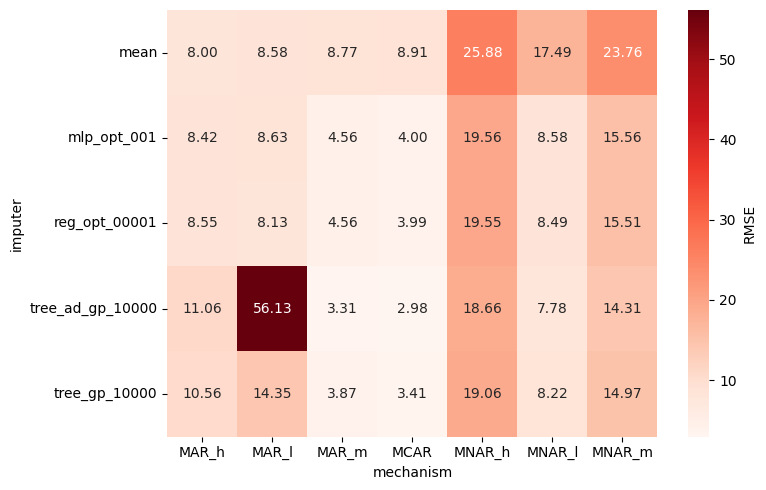

In [ ]:
# pivot RMSE by mechanism (rows) and imputer (columns) and plot a heatmap (average over missing_rate)
pivot = df.pivot_table(index='imputer', columns=['mechanism'], values='rmse', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label': 'RMSE'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

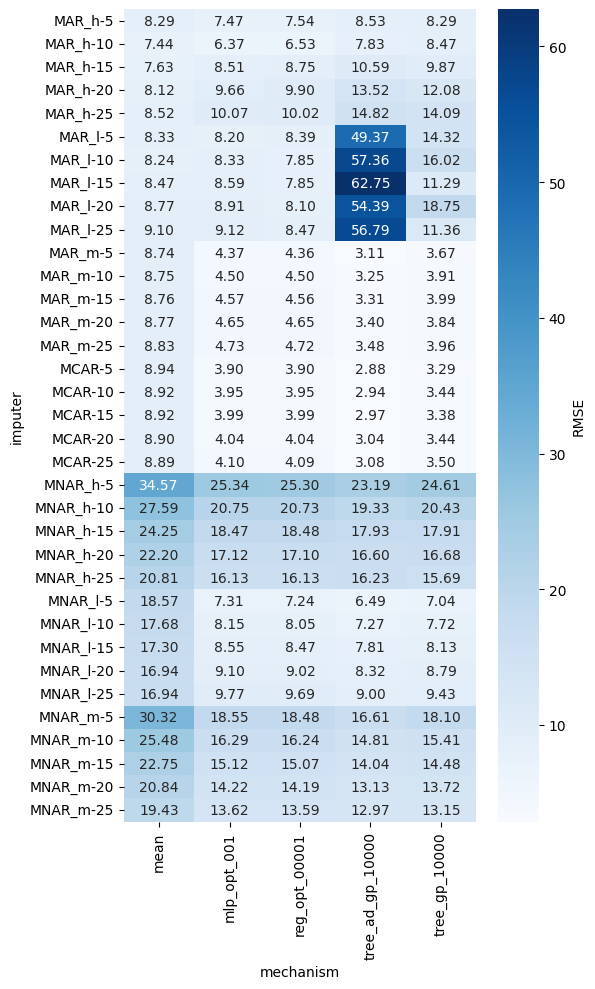

In [ ]:
# pivot RMSE by mechanism (rows) and imputer (columns) and plot a heatmap (average over missing_rate)
pivot = df.pivot_table(index=['mechanism','missing_rate'], columns='imputer', values='rmse', aggfunc='mean')

plt.figure(figsize=(6, 10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Blues', cbar_kws={'label': 'RMSE'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

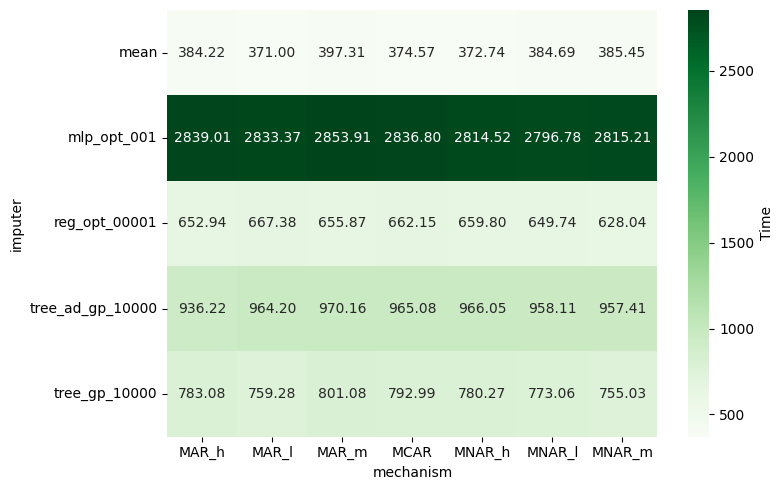

In [ ]:
pivot = df.pivot_table(index='imputer', columns='mechanism', values='ac_time', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Greens', cbar_kws={'label': 'Time'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

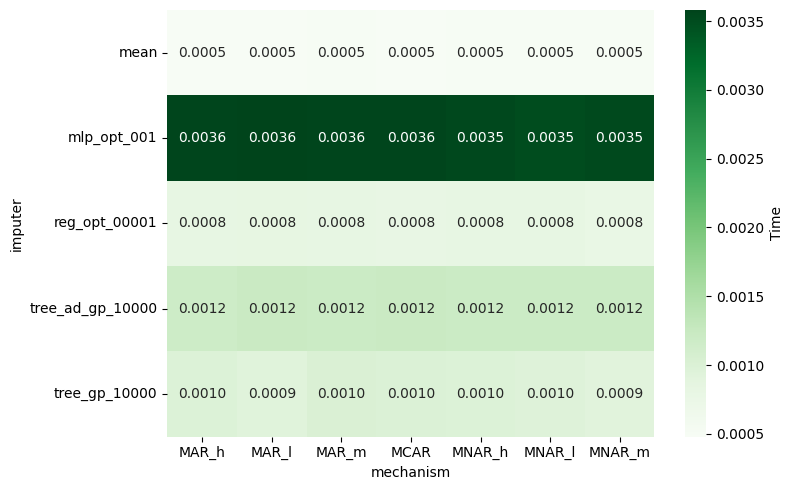

In [ ]:
# Convert it_time to log scale for better visualization
pivot = df.pivot_table(index='imputer', columns='mechanism', values='it_time', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap='Greens', cbar_kws={'label': 'Time'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

In [8]:
df_pats = pd.read_csv("imputation_results_by_patient_MCAR.csv")

  mechanism  patient           imputer   rmse
0      MCAR  A0NVTRV              mean  8.516
1      MCAR  A0NVTRV       mlp_opt_001  4.822
2      MCAR  A0NVTRV     reg_opt_00001  3.116
3      MCAR  A0NVTRV  tree_ad_gp_10000  2.420
4      MCAR  A0NVTRV     tree_gp_10000  2.706


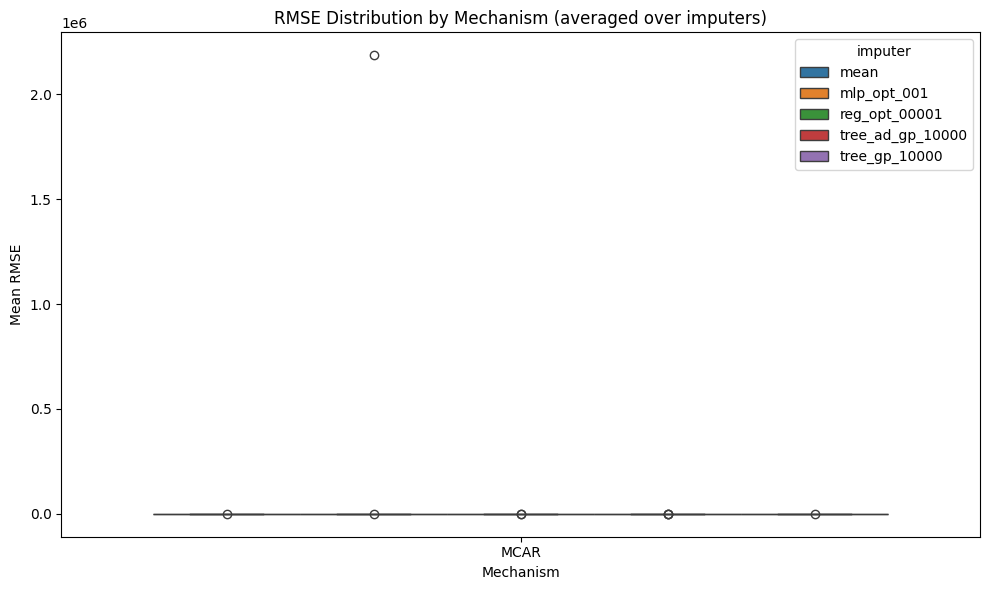

In [9]:
# Create boxplots showing RMSE distribution across patients for each mechanism
# Averaging over imputers for each patient-mechanism combination
# df_pats = df_pats[df_pats['patient'] != 'A36HR6Y']
df_grouped = df_pats.groupby(['mechanism', 'patient', 'imputer'])['rmse'].mean().reset_index()

print(df_grouped.head())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grouped, x='mechanism', y='rmse', hue='imputer')
plt.ylabel('Mean RMSE')
plt.xlabel('Mechanism')
plt.title('RMSE Distribution by Mechanism (averaged over imputers)')
plt.tight_layout()
plt.show()